
# Citi Bike 2025 Exploration Notebook (updated for cleaned CSVs)

This notebook is designed for the new workflow based on:

- `cleaned_combined.csv` - lean 2025 trip table
- `station_lookup.csv` - station metadata lookup
- `nyc2025weatherdata.csv` - hourly weather data

It is designed to:
- inspect schemas safely,
- aggregate the large trip file into a station-hour table in chunks,
- merge station lookup and hourly weather,
- engineer starter time-series features,
- produce useful EDA plots,
- and train simple baseline / starter models.

## Key idea

This notebook no longer cleans raw monthly Citi Bike files. That work belongs in the preprocessing script.

The notebook now focuses on converting an already-clean trip table into a station-hour modeling dataset.



## Roadmap

1. Set file paths and inspect the trip, station lookup, and weather schemas.
2. Aggregate the large trip CSV into a station-hour table using chunked processing.
3. Merge station lookup and hourly weather.
4. Create lag features and next-hour targets.
5. Run exploratory plots.
6. Train a naive baseline, Linear Regression, and Random Forest on the busiest stations.

## Input assumptions

The recommended `cleaned_combined.csv` keeps these columns:
- `started_at`
- `ended_at`
- `start_station_id`
- `end_station_id`
- `start_station_name`
- `end_station_name`
- `rideable_type`
- `member_casual`

The recommended `station_lookup.csv` keeps these columns:
- `station_id`
- `station_name`
- `lat`
- `lng`


In [1]:
# !pip install scikit-learn

In [2]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from pandas.errors import EmptyDataError
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


In [3]:

# --- Update these paths for your machine ---
TRIP_CSV_PATH = Path("cleaned_combined.csv")
STATION_LOOKUP_PATH = Path("station_lookup.csv")
WEATHER_CSV_PATH = Path("nyc2025weatherdata.csv")

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Chunk size for reading the large trip CSV.
# Increase if you have more RAM, decrease if memory is tight.
CHUNK_SIZE = 300_000

# Set to True if you want to ignore caches and rebuild intermediate files.
FORCE_REBUILD = False

# Modeling controls
TOP_N_STATIONS_FOR_MODEL = 150
TARGET_COL = "net_flow_next_hour"   # switch to departures_next_hour or arrivals_next_hour if preferred

print(f"Trip CSV exists: {TRIP_CSV_PATH.exists()} -> {TRIP_CSV_PATH}")
print(f"Station lookup exists: {STATION_LOOKUP_PATH.exists()} -> {STATION_LOOKUP_PATH}")
print(f"Weather CSV exists: {WEATHER_CSV_PATH.exists()} -> {WEATHER_CSV_PATH}")


Trip CSV exists: True -> cleaned_combined.csv
Station lookup exists: True -> station_lookup.csv
Weather CSV exists: True -> nyc2025weatherdata.csv


## Safe schema previews

In [4]:

# Safe trip preview: only read a few rows
preview = pd.read_csv(TRIP_CSV_PATH, nrows=5)
preview.columns = preview.columns.str.strip().str.lower()
preview.head()


,started_at,ended_at,start_station_id,end_station_id,start_station_name,end_station_name,rideable_type,member_casual
0,2025-01-01 14:52:26,2025-01-01 14:59:53,6182.02,5746.02,W 20 St & 7 Ave,E 10 St & 2 Ave,electric_bike,casual
1,2025-01-10 05:03:13,2025-01-10 05:13:13,6182.02,6004.07,W 20 St & 7 Ave,E 25 St & 1 Ave,classic_bike,member
2,2025-01-13 13:40:17,2025-01-13 13:47:05,5238.05,5137.11,St James Pl & Oliver St,Fulton St & William St,classic_bike,member
3,2025-01-10 08:29:16,2025-01-10 08:34:49,5238.05,5137.11,St James Pl & Oliver St,Fulton St & William St,electric_bike,member
4,2025-01-11 18:59:48,2025-01-11 19:13:21,6197.08,5414.06,E 33 St & 1 Ave,Allen St & Rivington St,electric_bike,member


In [5]:

preview.dtypes


started_at                str
ended_at                  str
start_station_id      float64
end_station_id        float64
start_station_name        str
end_station_name          str
rideable_type             str
member_casual             str
dtype: object

In [6]:

trip_columns = preview.columns.tolist()
print(trip_columns)


['started_at', 'ended_at', 'start_station_id', 'end_station_id', 'start_station_name', 'end_station_name', 'rideable_type', 'member_casual']


In [7]:

station_lookup_preview = pd.read_csv(STATION_LOOKUP_PATH, nrows=5)
station_lookup_preview.columns = station_lookup_preview.columns.str.strip().str.lower()
station_lookup_preview.head()


,station_id,station_name,lat,lng
0,1234.56,Morgan HCT Charging,40.708948,-73.932777
1,190 Morgan,190 Morgan,40.711072,-73.932096
2,1964.01,101 St & Fort Hamilton Pkwy,40.611240,-74.032820
3,2009.04,Shore Rd & 4 Ave,40.611500,-74.035130
4,2042.01,4 Ave & 99 St,40.613270,-74.033150


In [8]:

weather_preview = pd.read_csv(WEATHER_CSV_PATH, nrows=5)
weather_preview.columns = weather_preview.columns.str.strip()
weather_preview.head()


,location_id,time,temperature_2m (°F),precipitation (inch),rain (inch),snowfall (inch),snow_depth (ft),wind_speed_10m (mp/h),soil_temperature_0_to_7cm (°F),soil_temperature_7_to_28cm (°F),relative_humidity_2m (%),dew_point_2m (°F),apparent_temperature (°F),wind_gusts_10m (mp/h),wind_direction_10m (°)
0,0,2025-01-01T00:00,45.6,0.146,0.146,0.0,0.0,10.7,44.3,43.7,94,44.0,39.5,22.4,91
1,0,2025-01-01T01:00,46.8,0.035,0.035,0.0,0.0,9.3,44.6,43.7,96,45.8,41.8,23.7,92
2,0,2025-01-01T02:00,47.6,0.000,0.000,0.0,0.0,4.8,45.0,43.7,97,46.7,44.7,18.1,109
3,0,2025-01-01T03:00,48.0,0.000,0.000,0.0,0.0,5.4,45.3,43.8,99,47.7,45.1,10.1,171
4,0,2025-01-01T04:00,48.0,0.000,0.000,0.0,0.0,5.5,45.7,43.9,98,47.6,45.1,10.3,223



## Detect which station columns are available

The notebook prefers station IDs. If they are missing, it falls back to station names.

For the new cleaned CSV workflow, station IDs are strongly preferred.


In [9]:

def pick_station_columns(columns):
    columns = set(columns)

    start_key_col = None
    end_key_col = None
    key_mode = None

    if "start_station_id" in columns and "end_station_id" in columns:
        start_key_col = "start_station_id"
        end_key_col = "end_station_id"
        key_mode = "id"
    elif "start_station_name" in columns and "end_station_name" in columns:
        start_key_col = "start_station_name"
        end_key_col = "end_station_name"
        key_mode = "name"
    else:
        raise ValueError(
            "Could not find usable station key columns. Expected station ids or station names."
        )

    return start_key_col, end_key_col, key_mode

START_KEY_COL, END_KEY_COL, KEY_MODE = pick_station_columns(trip_columns)
print("Using start key column:", START_KEY_COL)
print("Using end key column:", END_KEY_COL)
print("Key mode:", KEY_MODE)


Using start key column: start_station_id
Using end key column: end_station_id
Key mode: id



## Prepare station lookup

The station lookup is merged after hourly aggregation, which keeps the large trip scan lighter.


In [10]:

def prepare_station_lookup(station_lookup_path, key_mode="id"):
    station_lookup = pd.read_csv(station_lookup_path)
    station_lookup.columns = station_lookup.columns.str.strip().str.lower()

    if key_mode == "id":
        if "station_id" not in station_lookup.columns:
            raise ValueError("station_lookup.csv must contain station_id when using station ids.")
        station_lookup = station_lookup.rename(columns={"station_id": "station_key"})
    else:
        if "station_name" not in station_lookup.columns:
            raise ValueError("station_lookup.csv must contain station_name when using station names.")
        station_lookup = station_lookup.rename(columns={"station_name": "station_key"})

    station_lookup["station_key"] = station_lookup["station_key"].astype("string")

    if "station_name" not in station_lookup.columns:
        station_lookup["station_name"] = station_lookup["station_key"]

    keep_cols = [c for c in ["station_key", "station_name", "lat", "lng"] if c in station_lookup.columns]
    station_lookup = station_lookup[keep_cols].drop_duplicates(subset=["station_key"])

    return station_lookup

station_lookup = prepare_station_lookup(STATION_LOOKUP_PATH, key_mode=KEY_MODE)
print(station_lookup.shape)
station_lookup.head()


(2428, 4)


,station_key,station_name,lat,lng
0,1234.56,Morgan HCT Charging,40.708948,-73.932777
1,190 Morgan,190 Morgan,40.711072,-73.932096
2,1964.01,101 St & Fort Hamilton Pkwy,40.611240,-74.032820
3,2009.04,Shore Rd & 4 Ave,40.611500,-74.035130
4,2042.01,4 Ave & 99 St,40.613270,-74.033150



## Chunked station-hour aggregation

This is the most important preprocessing step.

For each chunk of the trip CSV, we compute:
- hourly departures by start station,
- hourly arrivals by end station.

Then we combine everything into a station-hour table with:
- `departures`
- `arrivals`
- `net_flow = arrivals - departures`
- `total_activity = arrivals + departures`

The result is cached so you usually only need to scan the big trip CSV once.


In [11]:

def save_table_with_fallback(df, preferred_path):
    preferred_path = Path(preferred_path)
    try:
        df.to_parquet(preferred_path, index=False)
        return preferred_path
    except Exception as exc:
        fallback_path = preferred_path.with_suffix(".csv")
        print(f"Parquet save failed ({exc}). Saving CSV cache instead: {fallback_path}")
        df.to_csv(fallback_path, index=False)
        return fallback_path


def load_cached_table(preferred_path):
    if preferred_path.exists():
        try:
            return pd.read_parquet(preferred_path)
        except Exception as e:
            print(f"Failed to read parquet {preferred_path}: {e}")

    csv_fallback = preferred_path.with_suffix(".csv")
    if csv_fallback.exists():
        try:
            print(f"Loading cached table from {csv_fallback}")
            return pd.read_csv(csv_fallback, parse_dates=["hour"])
        except EmptyDataError:
            print(f"CSV cache is empty: {csv_fallback}")
            return None
        except Exception as e:
            print(f"Failed to read CSV fallback {csv_fallback}: {e}")
            return None

    return None


def aggregate_station_hour(
    trip_csv_path,
    trip_columns,
    start_key_col,
    end_key_col,
    chunksize=300_000,
    cache_path=None,
    force_rebuild=False,
):
    if cache_path is not None and not force_rebuild:
        cached = load_cached_table(cache_path)
        if cached is not None:
            return cached

    base_usecols = ["started_at", "ended_at", start_key_col, end_key_col]
    usecols = [c for c in base_usecols if c in trip_columns]

    dtype_map = {start_key_col: "string", end_key_col: "string"}

    departures = pd.Series(dtype="float64")
    arrivals = pd.Series(dtype="float64")

    reader = pd.read_csv(
        trip_csv_path,
        usecols=usecols,
        dtype=dtype_map,
        chunksize=chunksize,
        low_memory=True,
    )

    for chunk_idx, chunk in enumerate(reader, start=1):
        chunk.columns = chunk.columns.str.strip().str.lower()
        chunk = chunk.dropna(subset=["started_at", "ended_at", start_key_col, end_key_col]).copy()

        chunk["started_at"] = pd.to_datetime(chunk["started_at"], errors="coerce")
        chunk["ended_at"] = pd.to_datetime(chunk["ended_at"], errors="coerce")
        chunk = chunk.dropna(subset=["started_at", "ended_at"]).copy()

        chunk[start_key_col] = chunk[start_key_col].astype("string")
        chunk[end_key_col] = chunk[end_key_col].astype("string")

        chunk["start_hour"] = chunk["started_at"].dt.floor("h")
        chunk["end_hour"] = chunk["ended_at"].dt.floor("h")

        dep = chunk.groupby([start_key_col, "start_hour"]).size().astype("float64")
        arr = chunk.groupby([end_key_col, "end_hour"]).size().astype("float64")
        if departures.empty:
            departures = dep
        else:
            departures = departures.add(dep, fill_value=0)

        if arrivals.empty:
            arrivals = arr
        else:
            arrivals = arrivals.add(arr, fill_value=0)
        departures = departures.add(dep, fill_value=0)
        arrivals = arrivals.add(arr, fill_value=0)

        if chunk_idx % 5 == 0:
            print(f"Processed {chunk_idx} chunks...")

    departures = departures.rename("departures").reset_index()
    departures = departures.rename(columns={start_key_col: "station_key", "start_hour": "hour"})

    arrivals = arrivals.rename("arrivals").reset_index()
    arrivals = arrivals.rename(columns={end_key_col: "station_key", "end_hour": "hour"})

    station_hour = departures.merge(arrivals, on=["station_key", "hour"], how="outer")
    station_hour["departures"] = station_hour["departures"].fillna(0).astype("int32")
    station_hour["arrivals"] = station_hour["arrivals"].fillna(0).astype("int32")
    station_hour["station_key"] = station_hour["station_key"].astype("string")
    station_hour["hour"] = pd.to_datetime(station_hour["hour"])

    station_hour["net_flow"] = station_hour["arrivals"] - station_hour["departures"]
    station_hour["total_activity"] = station_hour["arrivals"] + station_hour["departures"]

    station_hour = station_hour.sort_values(["station_key", "hour"]).reset_index(drop=True)

    if cache_path is not None:
        saved_to = save_table_with_fallback(station_hour, cache_path)
        print(f"Saved station-hour cache to {saved_to}")

    return station_hour


In [12]:

station_hour_cache = OUTPUT_DIR / "station_hour_2025.parquet"
station_hour = aggregate_station_hour(
    trip_csv_path=TRIP_CSV_PATH,
    trip_columns=trip_columns,
    start_key_col=START_KEY_COL,
    end_key_col=END_KEY_COL,
    chunksize=CHUNK_SIZE,
    cache_path=station_hour_cache,
    force_rebuild=FORCE_REBUILD,
)

print(station_hour.shape)
station_hour.head()


(11966828, 6)


,station_key,hour,departures,arrivals,net_flow,total_activity
0,1234.56,2025-06-18 22:00:00,0,2,2,2
1,1234.56,2025-06-18 23:00:00,2,2,0,4
2,1234.56,2025-06-19 23:00:00,2,0,-2,2
3,1234.56,2025-06-20 09:00:00,2,2,0,4
4,1234.56,2025-06-20 12:00:00,2,2,0,4


In [13]:

print("Unique stations:", station_hour["station_key"].nunique())
print("Hour range:", station_hour["hour"].min(), "to", station_hour["hour"].max())
print("Total departures:", int(station_hour["departures"].sum()))
print("Total arrivals:", int(station_hour["arrivals"].sum()))
station_hour.describe(include="all").T


Unique stations: 2428
Hour range: 2024-12-31 12:00:00 to 2025-12-31 23:00:00
Total departures: 91247508
Total arrivals: 91247508


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
station_key,11966828,2428,6331.01,8490,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour,11966828,NaN,NaN,NaN,2025-07-05 15:19:26.750084,2024-12-31 12:00:00,2025-04-14 08:00:00,2025-07-08 01:00:00,2025-09-27 17:00:00,2025-12-31 23:00:00,NaN
departures,11966828.0,NaN,NaN,NaN,7.625037,0.0,2.0,4.0,10.0,428.0,11.504604
arrivals,11966828.0,NaN,NaN,NaN,7.625037,0.0,2.0,4.0,10.0,442.0,11.621623
net_flow,11966828.0,NaN,NaN,NaN,0.0,-274.0,-2.0,0.0,2.0,268.0,7.657432
total_activity,11966828.0,NaN,NaN,NaN,15.250074,2.0,2.0,6.0,18.0,844.0,21.822003



## Merge station lookup and hourly weather

We merge station metadata after trip aggregation, then merge weather on the hourly timestamp.


In [14]:

def load_weather(weather_csv_path):
    weather = pd.read_csv(weather_csv_path)

    rename_map = {
        "time": "hour",
        "temperature_2m (degF)": "temperature_f",
        "temperature_2m (°F)": "temperature_f",
        "precipitation (inch)": "precipitation_in",
        "rain (inch)": "rain_in",
        "snowfall (inch)": "snowfall_in",
        "snow_depth (ft)": "snow_depth_ft",
        "wind_speed_10m (mp/h)": "wind_speed_mph",
        "relative_humidity_2m (%)": "relative_humidity_pct",
        "dew_point_2m (degF)": "dew_point_f",
        "dew_point_2m (°F)": "dew_point_f",
        "apparent_temperature (degF)": "apparent_temperature_f",
        "apparent_temperature (°F)": "apparent_temperature_f",
        "wind_gusts_10m (mp/h)": "wind_gusts_mph",
        "wind_direction_10m (deg)": "wind_direction_deg",
        "wind_direction_10m (°)": "wind_direction_deg",
        "cloud_cover (%)": "cloud_cover_pct",
        "surface_pressure (hPa)": "surface_pressure_hpa",
        "visibility (ft)": "visibility_ft",
    }

    weather = weather.rename(columns=rename_map)
    weather.columns = [c.strip() for c in weather.columns]

    if "hour" not in weather.columns:
        raise ValueError("Could not find a time/hour column in the weather CSV.")

    weather["hour"] = pd.to_datetime(weather["hour"], errors="coerce")
    weather = weather.dropna(subset=["hour"]).copy()
    weather = weather.sort_values("hour").drop_duplicates(subset=["hour"])

    return weather

weather = load_weather(WEATHER_CSV_PATH)
print(weather.shape)
weather.head()


(8760, 15)


,location_id,hour,temperature_f,precipitation_in,rain_in,snowfall_in,snow_depth_ft,wind_speed_mph,soil_temperature_0_to_7cm (°F),soil_temperature_7_to_28cm (°F),relative_humidity_pct,dew_point_f,apparent_temperature_f,wind_gusts_mph,wind_direction_deg
0,0,2025-01-01 00:00:00,45.6,0.146,0.146,0.0,0.0,10.7,44.3,43.7,94,44.0,39.5,22.4,91
1,0,2025-01-01 01:00:00,46.8,0.035,0.035,0.0,0.0,9.3,44.6,43.7,96,45.8,41.8,23.7,92
2,0,2025-01-01 02:00:00,47.6,0.000,0.000,0.0,0.0,4.8,45.0,43.7,97,46.7,44.7,18.1,109
35043,4,2025-01-01 03:00:00,48.1,0.000,0.000,0.0,0.0,6.6,46.9,45.4,97,47.3,44.6,13.6,220
4,0,2025-01-01 04:00:00,48.0,0.000,0.000,0.0,0.0,5.5,45.7,43.9,98,47.6,45.1,10.3,223


In [15]:

station_hour_enriched = station_hour.merge(
    station_lookup,
    on="station_key",
    how="left",
)

station_hour_weather = station_hour_enriched.merge(weather, on="hour", how="left")
print(station_hour_weather.shape)
station_hour_weather.head()


(11966828, 23)


,station_key,hour,departures,arrivals,net_flow,total_activity,station_name,lat,lng,location_id,temperature_f,precipitation_in,rain_in,snowfall_in,snow_depth_ft,wind_speed_mph,soil_temperature_0_to_7cm (°F),soil_temperature_7_to_28cm (°F),relative_humidity_pct,dew_point_f,apparent_temperature_f,wind_gusts_mph,wind_direction_deg
0,1234.56,2025-06-18 22:00:00,0,2,2,2,Morgan HCT Charging,40.708948,-73.932777,1.0,70.2,0.004,0.004,0.0,0.0,0.8,72.5,69.8,100.0,70.1,77.8,5.8,214.0
1,1234.56,2025-06-18 23:00:00,2,2,0,4,Morgan HCT Charging,40.708948,-73.932777,3.0,71.4,0.004,0.004,0.0,0.0,2.7,72.5,69.4,98.0,71.0,78.8,7.6,195.0
2,1234.56,2025-06-19 23:00:00,2,0,-2,2,Morgan HCT Charging,40.708948,-73.932777,0.0,73.0,0.000,0.000,0.0,0.0,10.6,74.5,73.6,83.0,67.5,75.2,23.3,234.0
3,1234.56,2025-06-20 09:00:00,2,2,0,4,Morgan HCT Charging,40.708948,-73.932777,3.0,72.6,0.000,0.000,0.0,0.0,11.3,71.7,71.2,55.0,55.5,69.6,26.8,284.0
4,1234.56,2025-06-20 12:00:00,2,2,0,4,Morgan HCT Charging,40.708948,-73.932777,2.0,79.3,0.000,0.000,0.0,0.0,11.2,78.9,72.3,46.0,56.8,79.9,27.7,286.0


In [16]:

enriched_cache = OUTPUT_DIR / "station_hour_weather_2025.parquet"
saved_to = save_table_with_fallback(station_hour_weather, enriched_cache)
print(f"Saved enriched station-hour table to {saved_to}")


Saved enriched station-hour table to outputs\station_hour_weather_2025.parquet



## Feature engineering

We create:
- calendar features,
- lag features by station,
- rolling averages by station,
- next-hour targets.

Important: rolling features are computed within each station group.


In [17]:

def engineer_features(df):
    df = df.copy().sort_values(["station_key", "hour"]).reset_index(drop=True)

    df["hour_of_day"] = df["hour"].dt.hour
    df["day_of_week"] = df["hour"].dt.dayofweek
    df["month"] = df["hour"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    group = df.groupby("station_key", sort=False)

    base_cols = ["departures", "arrivals", "net_flow", "total_activity"]
    for col in base_cols:
        df[f"{col}_lag_1"] = group[col].shift(1)
        df[f"{col}_lag_2"] = group[col].shift(2)
        df[f"{col}_lag_24"] = group[col].shift(24)
        df[f"{col}_roll_3"] = group[col].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
        df[f"{col}_roll_24"] = group[col].transform(lambda s: s.shift(1).rolling(24, min_periods=1).mean())

    df["departures_next_hour"] = group["departures"].shift(-1)
    df["arrivals_next_hour"] = group["arrivals"].shift(-1)
    df["net_flow_next_hour"] = group["net_flow"].shift(-1)

    return df


In [18]:

feature_cache = OUTPUT_DIR / "feature_df_2025.parquet"

if not FORCE_REBUILD:
    feature_df = load_cached_table(feature_cache)
else:
    feature_df = None

if feature_df is None:
    feature_df = engineer_features(station_hour_weather)
    saved_to = save_table_with_fallback(feature_df, feature_cache)
    print(f"Saved feature table to {saved_to}")

print(feature_df.shape)
feature_df[["station_key", "hour", "departures", "arrivals", "net_flow", TARGET_COL]].head(10)


(11966828, 50)


,station_key,hour,departures,arrivals,net_flow,net_flow_next_hour
0,1234.56,2025-06-18 22:00:00,0,2,2,0.0
1,1234.56,2025-06-18 23:00:00,2,2,0,-2.0
2,1234.56,2025-06-19 23:00:00,2,0,-2,0.0
3,1234.56,2025-06-20 09:00:00,2,2,0,0.0
4,1234.56,2025-06-20 12:00:00,2,2,0,0.0
5,1234.56,2025-06-20 14:00:00,2,2,0,0.0
6,1234.56,2025-06-20 15:00:00,2,2,0,0.0
7,1234.56,2025-06-20 19:00:00,2,2,0,-2.0
8,1234.56,2025-06-20 23:00:00,4,2,-2,2.0
9,1234.56,2025-06-21 06:00:00,0,2,2,2.0


In [19]:

feature_df.describe(include="all").T.head(50)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
station_key,11966828,2428,6331.01,8490,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour,11966828,NaN,NaN,NaN,2025-07-05 15:19:26.750084,2024-12-31 12:00:00,2025-04-14 08:00:00,2025-07-08 01:00:00,2025-09-27 17:00:00,2025-12-31 23:00:00,NaN
departures,11966828.0,NaN,NaN,NaN,7.625037,0.0,2.0,4.0,10.0,428.0,11.504604
arrivals,11966828.0,NaN,NaN,NaN,7.625037,0.0,2.0,4.0,10.0,442.0,11.621623
net_flow,11966828.0,NaN,NaN,NaN,0.0,-274.0,-2.0,0.0,2.0,268.0,7.657432
total_activity,11966828.0,NaN,NaN,NaN,15.250074,2.0,2.0,6.0,18.0,844.0,21.822003
station_name,11966828,2324,3 Ave & E 82 St,12059,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,11966828.0,NaN,NaN,NaN,40.740604,0.0,40.697926,40.73715,40.771497,40.8863,0.075596
lng,11966828.0,NaN,NaN,NaN,-73.952628,-118.481518,-73.983776,-73.954131,-73.924352,0.0,0.123191
location_id,11966678.0,NaN,NaN,NaN,2.001756,0.0,1.0,2.0,3.0,4.0,1.424407


## Exploratory analysis

In [20]:

city_hour = (
    feature_df.groupby("hour", as_index=False)[["departures", "arrivals", "net_flow", "total_activity"]]
    .sum()
    .sort_values("hour")
)

city_hour.head()


,hour,departures,arrivals,net_flow,total_activity
0,2024-12-31 12:00:00,2,0,-2,2
1,2024-12-31 13:00:00,4,0,-4,4
2,2024-12-31 14:00:00,6,0,-6,6
3,2024-12-31 15:00:00,4,0,-4,4
4,2024-12-31 18:00:00,2,0,-2,2


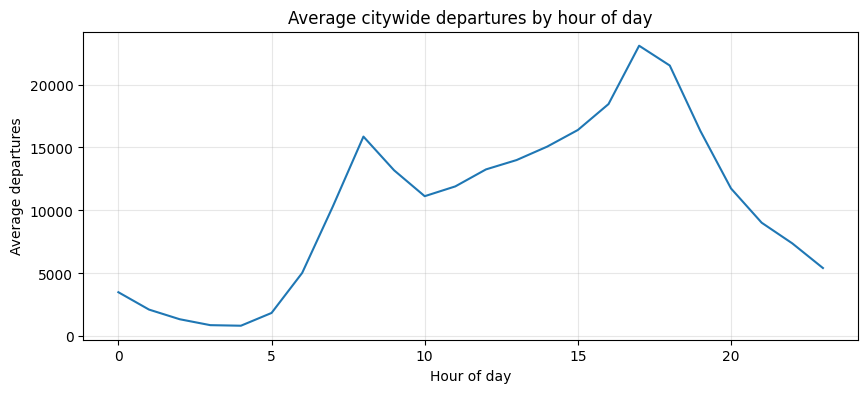

In [21]:

# 1) Average citywide departures by hour of day
by_hour = (
    city_hour.assign(hour_of_day=city_hour["hour"].dt.hour)
    .groupby("hour_of_day", as_index=False)["departures"]
    .mean()
)

plt.figure(figsize=(10, 4))
plt.plot(by_hour["hour_of_day"], by_hour["departures"])
plt.title("Average citywide departures by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Average departures")
plt.grid(True, alpha=0.3)
plt.show()


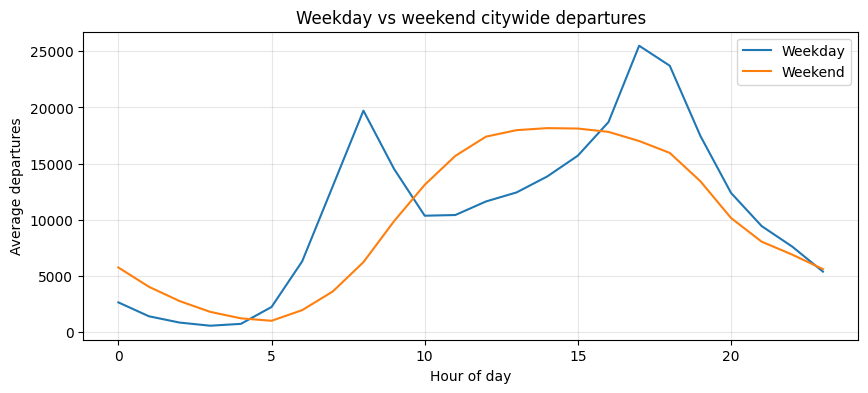

In [22]:

# 2) Weekday vs weekend citywide departures
city_hour_plot = city_hour.copy()
city_hour_plot["hour_of_day"] = city_hour_plot["hour"].dt.hour
city_hour_plot["is_weekend"] = city_hour_plot["hour"].dt.dayofweek >= 5

weekday = city_hour_plot.loc[~city_hour_plot["is_weekend"]].groupby("hour_of_day")["departures"].mean()
weekend = city_hour_plot.loc[city_hour_plot["is_weekend"]].groupby("hour_of_day")["departures"].mean()

plt.figure(figsize=(10, 4))
plt.plot(weekday.index, weekday.values, label="Weekday")
plt.plot(weekend.index, weekend.values, label="Weekend")
plt.title("Weekday vs weekend citywide departures")
plt.xlabel("Hour of day")
plt.ylabel("Average departures")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


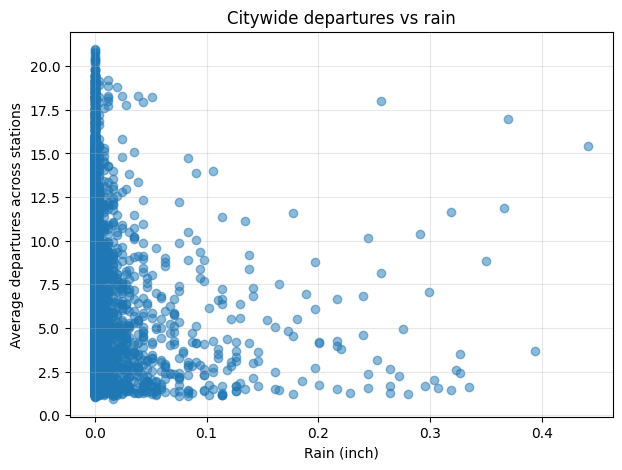

In [23]:

# 3) Rain vs departures
if "rain_in" in feature_df.columns:
    rain_hour = feature_df.groupby("hour", as_index=False)[["departures", "rain_in"]].mean()
    plt.figure(figsize=(7, 5))
    plt.scatter(rain_hour["rain_in"], rain_hour["departures"], alpha=0.5)
    plt.title("Citywide departures vs rain")
    plt.xlabel("Rain (inch)")
    plt.ylabel("Average departures across stations")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("rain_in column not found in weather data.")


In [24]:

# 4) Busiest stations
station_activity = (
    feature_df.groupby(["station_key", "station_name"], dropna=False, as_index=False)["total_activity"]
    .sum()
    .sort_values("total_activity", ascending=False)
)
station_activity.head(20)


,station_key,station_name,total_activity
1190,6140.05,W 21 St & 6 Ave,667396
1247,6233.04,Pier 61 at Chelsea Piers,601878
1048,5788.13,Lafayette St & E 8 St,587972
857,5329.03,West St & Chambers St,560886
1310,6331.01,W 31 St & 7 Ave,552422
1394,6492.08,9 Ave & W 33 St,541082
1084,5905.12,Broadway & E 14 St,533820
1085,5905.14,University Pl & E 14 St,520874
1527,6726.01,11 Ave & W 41 St,516398
1637,6948.10,Broadway & W 58 St,497616



## Starter modeling dataset

To keep the first model manageable, we train on the busiest stations only.

Why this helps:
- avoids a huge sparse one-hot matrix for every station in the city,
- focuses first on stations with the strongest signal,
- gives you a fast baseline before scaling up.


In [25]:

model_df = feature_df.copy()

busy_stations = (
    model_df.groupby("station_key")["total_activity"]
    .sum()
    .sort_values(ascending=False)
    .head(TOP_N_STATIONS_FOR_MODEL)
    .index
)
model_df = model_df[model_df["station_key"].isin(busy_stations)].copy()

needed_cols = [
    "station_key", "hour", TARGET_COL,
    "hour_of_day", "day_of_week", "month", "is_weekend",
    "departures", "arrivals", "net_flow", "total_activity",
    "departures_lag_1", "departures_lag_2", "departures_lag_24",
    "arrivals_lag_1", "arrivals_lag_2", "arrivals_lag_24",
    "net_flow_lag_1", "net_flow_lag_2", "net_flow_lag_24",
    "total_activity_lag_1", "total_activity_lag_2", "total_activity_lag_24",
    "departures_roll_3", "departures_roll_24",
    "arrivals_roll_3", "arrivals_roll_24",
    "net_flow_roll_3", "net_flow_roll_24",
    "total_activity_roll_3", "total_activity_roll_24",
]

weather_candidates = [
    "temperature_f", "precipitation_in", "rain_in", "snowfall_in", "snow_depth_ft",
    "wind_speed_mph", "relative_humidity_pct", "dew_point_f", "apparent_temperature_f",
    "wind_gusts_mph", "wind_direction_deg", "cloud_cover_pct", "surface_pressure_hpa",
    "visibility_ft",
]
for c in weather_candidates:
    if c in model_df.columns:
        needed_cols.append(c)

needed_cols = [c for c in needed_cols if c in model_df.columns]
model_df = model_df[needed_cols].dropna(subset=[TARGET_COL]).copy()

print(model_df.shape)
model_df.head()


(1185444, 42)


,station_key,hour,net_flow_next_hour,hour_of_day,day_of_week,month,is_weekend,departures,arrivals,net_flow,total_activity,departures_lag_1,departures_lag_2,departures_lag_24,arrivals_lag_1,arrivals_lag_2,arrivals_lag_24,net_flow_lag_1,net_flow_lag_2,net_flow_lag_24,total_activity_lag_1,total_activity_lag_2,total_activity_lag_24,departures_roll_3,departures_roll_24,arrivals_roll_3,arrivals_roll_24,net_flow_roll_3,net_flow_roll_24,total_activity_roll_3,total_activity_roll_24,temperature_f,precipitation_in,rain_in,snowfall_in,snow_depth_ft,wind_speed_mph,relative_humidity_pct,dew_point_f,apparent_temperature_f,wind_gusts_mph,wind_direction_deg
2099365,4395.07,2025-01-01 00:00:00,-4.0,0,2,1,0,8,2,-6,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.6,0.146,0.146,0.0,0.0,10.7,94.0,44.0,39.5,22.4,91.0
2099366,4395.07,2025-01-01 01:00:00,0.0,1,2,1,0,6,2,-4,8,8.0,NaN,NaN,2.0,NaN,NaN,-6.0,NaN,NaN,10.0,NaN,NaN,8.000000,8.000000,2.000000,2.0,-6.000000,-6.000000,10.000000,10.000000,46.8,0.035,0.035,0.0,0.0,9.3,96.0,45.8,41.8,23.7,92.0
2099367,4395.07,2025-01-01 02:00:00,4.0,2,2,1,0,2,2,0,4,6.0,8.0,NaN,2.0,2.0,NaN,-4.0,-6.0,NaN,8.0,10.0,NaN,7.000000,7.000000,2.000000,2.0,-5.000000,-5.000000,9.000000,9.000000,47.6,0.000,0.000,0.0,0.0,4.8,97.0,46.7,44.7,18.1,109.0
2099368,4395.07,2025-01-01 06:00:00,2.0,6,2,1,0,2,6,4,8,2.0,6.0,NaN,2.0,2.0,NaN,0.0,-4.0,NaN,4.0,8.0,NaN,5.333333,5.333333,2.000000,2.0,-3.333333,-3.333333,7.333333,7.333333,47.0,0.000,0.000,0.0,0.0,9.1,98.0,46.6,42.3,17.7,254.0
2099369,4395.07,2025-01-01 07:00:00,-2.0,7,2,1,0,0,2,2,2,2.0,2.0,NaN,6.0,2.0,NaN,4.0,0.0,NaN,8.0,4.0,NaN,3.333333,4.500000,3.333333,3.0,0.000000,-1.500000,6.666667,7.500000,45.0,0.000,0.000,0.0,0.0,10.0,97.0,44.2,39.4,20.1,268.0


In [26]:

# Chronological split
model_df = model_df.sort_values("hour").reset_index(drop=True)
unique_hours = np.sort(model_df["hour"].unique())

train_cutoff = unique_hours[int(len(unique_hours) * 0.70)]
valid_cutoff = unique_hours[int(len(unique_hours) * 0.85)]

train_df = model_df[model_df["hour"] < train_cutoff].copy()
valid_df = model_df[(model_df["hour"] >= train_cutoff) & (model_df["hour"] < valid_cutoff)].copy()
test_df = model_df[model_df["hour"] >= valid_cutoff].copy()

print("Train:", train_df["hour"].min(), "to", train_df["hour"].max(), train_df.shape)
print("Valid:", valid_df["hour"].min(), "to", valid_df["hour"].max(), valid_df.shape)
print("Test:", test_df["hour"].min(), "to", test_df["hour"].max(), test_df.shape)


Train: 2024-12-31 12:00:00 to 2025-09-13 08:00:00 (837931, 42)
Valid: 2025-09-13 09:00:00 to 2025-11-07 03:00:00 (179522, 42)
Test: 2025-11-07 04:00:00 to 2025-12-31 22:00:00 (167991, 42)


In [27]:

feature_cols = [c for c in model_df.columns if c not in ["hour", TARGET_COL]]
X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET_COL].copy()
X_valid = valid_df[feature_cols].copy()
y_valid = valid_df[TARGET_COL].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET_COL].copy()

categorical_features = [c for c in ["station_key"] if c in feature_cols]
numeric_features = [c for c in feature_cols if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)


In [28]:

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    return {
        "rmse": rmse,
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }

results = []

# Naive baseline: predict next hour using the current hour value when possible.
if TARGET_COL == "departures_next_hour" and "departures" in test_df.columns:
    naive_pred = test_df["departures"].to_numpy()
elif TARGET_COL == "net_flow_next_hour" and "net_flow" in test_df.columns:
    naive_pred = test_df["net_flow"].to_numpy()
elif TARGET_COL == "arrivals_next_hour" and "arrivals" in test_df.columns:
    naive_pred = test_df["arrivals"].to_numpy()
else:
    naive_pred = np.repeat(y_train.mean(), len(y_test))

baseline_metrics = regression_metrics(y_test, naive_pred)
baseline_metrics["model"] = "Naive baseline"
results.append(baseline_metrics)

linreg = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LinearRegression()),
    ]
)
linreg.fit(X_train, y_train)
linreg_pred = linreg.predict(X_test)
linreg_metrics = regression_metrics(y_test, linreg_pred)
linreg_metrics["model"] = "Linear Regression"
results.append(linreg_metrics)

rf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=50,
                max_depth=10,
                min_samples_leaf=20,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_metrics = regression_metrics(y_test, rf_pred)
rf_metrics["model"] = "Random Forest"
results.append(rf_metrics)

results_df = pd.DataFrame(results)[["model", "rmse", "mae", "r2"]].sort_values("rmse")
results_df


,model,rmse,mae,r2
2,Random Forest,9.914952,6.654513,0.259617
1,Linear Regression,10.691836,7.063787,0.139047
0,Naive baseline,13.011282,8.932145,-0.275015


In [29]:

comparison = test_df[["hour", "station_key", TARGET_COL]].copy()
comparison["naive_pred"] = naive_pred
comparison["linreg_pred"] = linreg_pred
comparison["rf_pred"] = rf_pred
comparison.head()


,hour,station_key,net_flow_next_hour,naive_pred,linreg_pred,rf_pred
1017453,2025-11-07 04:00:00,6925.09,4.0,-2,-0.352137,-0.109874
1017454,2025-11-07 04:00:00,6257.06,0.0,-4,-0.616159,-0.738125
1017455,2025-11-07 04:00:00,5561.04,-6.0,-4,-1.369921,-0.494555
1017456,2025-11-07 04:00:00,6889.12,16.0,2,0.946164,0.145397
1017457,2025-11-07 04:00:00,5626.15,2.0,-6,-2.050353,-0.123315


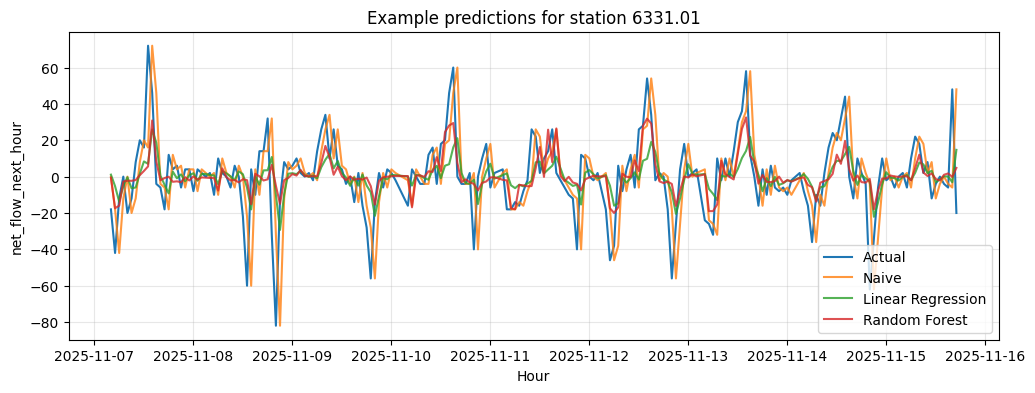

In [30]:

# Plot actual vs predictions for one example busy station
example_station = comparison["station_key"].value_counts().index[0]
plot_df = comparison[comparison["station_key"] == example_station].sort_values("hour").head(200)

plt.figure(figsize=(12, 4))
plt.plot(plot_df["hour"], plot_df[TARGET_COL], label="Actual")
plt.plot(plot_df["hour"], plot_df["naive_pred"], label="Naive", alpha=0.8)
plt.plot(plot_df["hour"], plot_df["linreg_pred"], label="Linear Regression", alpha=0.8)
plt.plot(plot_df["hour"], plot_df["rf_pred"], label="Random Forest", alpha=0.8)
plt.title(f"Example predictions for station {example_station}")
plt.xlabel("Hour")
plt.ylabel(TARGET_COL)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



## Suggested next steps

1. Save the station-hour table once, then do most experimentation on that smaller file.
2. Add holiday and special-event features.
3. Compare targets:
   - `departures_next_hour`
   - `arrivals_next_hour`
   - `net_flow_next_hour`
4. Try more time-series-aware models later, such as HistGradientBoosting, XGBoost, or LightGBM.
5. Add station clustering and commuter-vs-leisure segmentation once the base forecasting pipeline is stable.
6. Consider creating a second pass that aggregates member/casual and rideable-type shares by station-hour.
